# Sales Customer Analysis

## Overview
This notebook explores the part of the **Classic Models** sample database which is sales customer analysis using SQL and Python. The database contains business data for a fictitious company that sells classic car models, and it includes the following key tables:

- `customers`: Information about clients worldwide
- `employees`: Sales staff and reporting structure
- `offices`: Office locations
- `payments`: Customer payments history

## Purpose
The goal is to run 25 useful SQL queries to extract business insights such as:

- Customer distribution by country
- Sales performance and revenue
- Employee hierarchy and office staffing
- Payment trends and customer behavior

## Tools Used
- **SQLAlchemy**: For MySQL database connection
- **pandas**: To display query results in clean tabular form

## Key Insights
- Identify top-paying customers and underperforming regions
- Understand how employees are distributed and managed
- Spot customers without sales reps or payment records
- Track revenue by month and by office

## ERD (Entity-Relationship Diagram)

Below is the **Entity-Relationship Diagram (ERD)** showing the relationships between tables in the database:

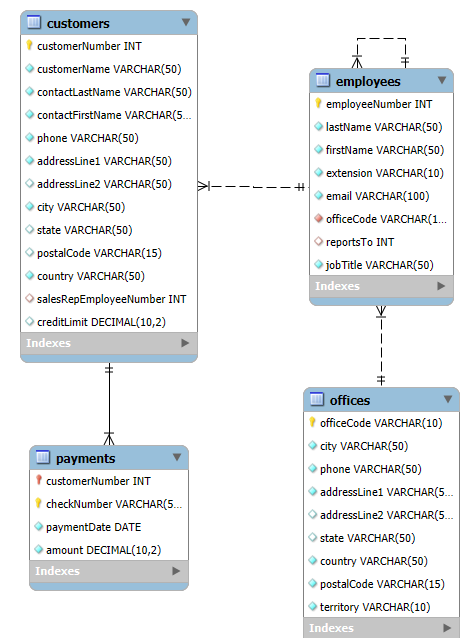

## Code

In [5]:
import pandas as pd
from sqlalchemy import create_engine

# Create SQLAlchemy engine
username = 'root'
password = 'haikal98'
host = 'localhost'
database = 'classicmodels'

engine = create_engine(f'mysql+mysqlconnector://{username}:{password}@{host}/{database}')

# Dictionary of SQL queries
queries = {
    "Customers by Country":
        "SELECT country, customerName FROM customers ORDER BY country",

    "Total Number of Customers":
        "SELECT COUNT(*) AS total_customers FROM customers",

    "Employees and Job Titles":
        "SELECT employeeNumber, firstName, lastName, jobTitle FROM employees",

    "Employees and Office City":
        """
        SELECT e.firstName, e.lastName, o.city 
        FROM employees e
        JOIN offices o ON e.officeCode = o.officeCode
        """,

    "Customers and Sales Reps":
        """
        SELECT c.customerName, e.firstName AS salesRepFirstName, e.lastName AS salesRepLastName 
        FROM customers c
        JOIN employees e ON c.salesRepEmployeeNumber = e.employeeNumber
        """,

    "Employees per Office":
        """
        SELECT o.city, COUNT(e.employeeNumber) AS num_employees 
        FROM offices o
        LEFT JOIN employees e ON o.officeCode = e.officeCode
        GROUP BY o.city
        """,

    "Employee Reporting Hierarchy":
        """
        SELECT e1.firstName AS employee, e2.firstName AS reportsTo 
        FROM employees e1
        LEFT JOIN employees e2 ON e1.reportsTo = e2.employeeNumber
        """,

    "Total Payments per Customer":
        """
        SELECT customerNumber, SUM(amount) AS total_payments 
        FROM payments 
        GROUP BY customerNumber
        """,

    "Customers with No Payments":
        """
        SELECT c.customerName 
        FROM customers c
        LEFT JOIN payments p ON c.customerNumber = p.customerNumber
        WHERE p.customerNumber IS NULL
        """,

    "Top 5 Customers by Total Payments":
        """
        SELECT c.customerName, SUM(p.amount) AS total_paid
        FROM customers c
        JOIN payments p ON c.customerNumber = p.customerNumber
        GROUP BY c.customerName
        ORDER BY total_paid DESC
        LIMIT 5
        """,

    "Customers from USA":
        "SELECT customerName FROM customers WHERE country = 'USA'",

    "Customer Count per Country":
        """
        SELECT country, COUNT(*) AS total_customers 
        FROM customers 
        GROUP BY country
        ORDER BY total_customers DESC
        """,

    "Employees by Office Location":
        """
        SELECT o.city, e.firstName, e.lastName 
        FROM employees e
        JOIN offices o ON e.officeCode = o.officeCode
        ORDER BY o.city
        """,

    "Payments in 2003":
        "SELECT * FROM payments WHERE YEAR(paymentDate) = 2003",

    "Monthly Payment Summary":
        """
        SELECT MONTH(paymentDate) AS month, SUM(amount) AS total_amount
        FROM payments
        GROUP BY MONTH(paymentDate)
        ORDER BY month
        """,

    "Customers with High Credit Limit":
        """
        SELECT customerName, creditLimit 
        FROM customers 
        WHERE creditLimit > 50000
        """,

    "Employees Who Are Managers":
        """
        SELECT DISTINCT e2.employeeNumber, e2.firstName, e2.lastName 
        FROM employees e1
        JOIN employees e2 ON e1.reportsTo = e2.employeeNumber
        """,

    "Offices per Country":
        """
        SELECT country, COUNT(*) AS office_count 
        FROM offices 
        GROUP BY country
        """,

    "Average Credit Limit by Country":
        """
        SELECT country, ROUND(AVG(creditLimit), 2) AS avg_credit 
        FROM customers 
        GROUP BY country
        """,

    "Employees Without a Manager":
        """
        SELECT firstName, lastName 
        FROM employees 
        WHERE reportsTo IS NULL
        """,

    "Customers Who Paid Above Their Credit Limit":
        """
        SELECT c.customerName, c.creditLimit, SUM(p.amount) AS totalPaid
        FROM customers c
        JOIN payments p ON c.customerNumber = p.customerNumber
        GROUP BY c.customerNumber
        HAVING totalPaid > c.creditLimit
        """,

    "Top-Selling Employees by Customer Payments":
        """
        SELECT e.employeeNumber, e.firstName, e.lastName, SUM(p.amount) AS totalSales
        FROM employees e
        JOIN customers c ON e.employeeNumber = c.salesRepEmployeeNumber
        JOIN payments p ON c.customerNumber = p.customerNumber
        GROUP BY e.employeeNumber
        ORDER BY totalSales DESC
        LIMIT 3
        """,

    "Monthly Revenue Breakdown by Office":
        """
        SELECT o.city AS officeCity, MONTH(p.paymentDate) AS month, SUM(p.amount) AS monthlyRevenue
        FROM offices o
        JOIN employees e ON o.officeCode = e.officeCode
        JOIN customers c ON e.employeeNumber = c.salesRepEmployeeNumber
        JOIN payments p ON c.customerNumber = p.customerNumber
        GROUP BY o.city, MONTH(p.paymentDate)
        ORDER BY o.city, month
        """,

    "Customers Without Assigned Sales Rep":
        """
        SELECT customerName, country 
        FROM customers 
        WHERE salesRepEmployeeNumber IS NULL
        """,

    "Employee Hierarchy with Manager and Office":
        """
        SELECT 
            e.employeeNumber AS empID,
            e.firstName AS employeeFirstName,
            e.lastName AS employeeLastName,
            m.firstName AS managerFirstName,
            m.lastName AS managerLastName,
            o.city AS officeCity
        FROM employees e
        LEFT JOIN employees m ON e.reportsTo = m.employeeNumber
        JOIN offices o ON e.officeCode = o.officeCode
        """
}

# Function to print formatted divider
def print_divider(title):
    print("\n" + "=" * 80)
    print(f"{title}".center(80))
    print("=" * 80 + "\n")

# Execute and display results with dividers
for title, sql in queries.items():
    print_divider(title)
    df = pd.read_sql(sql, engine)
    print(df)

# Cleanup
engine.dispose()



                              Customers by Country                              

       country                  customerName
0    Australia    Australian Collectors, Co.
1    Australia       Anna's Decorations, Ltd
2    Australia     Souveniers And Things Co.
3    Australia   Australian Gift Network, Co
4    Australia  Australian Collectables, Ltd
..         ...                           ...
117        USA              FunGiftIdeas.com
118        USA   West Coast Collectables Co.
119        USA  Motor Mint Distributors Inc.
120        USA      Signal Collectibles Ltd.
121        USA          Diecast Collectables

[122 rows x 2 columns]

                           Total Number of Customers                            

   total_customers
0              122

                            Employees and Job Titles                            

    employeeNumber firstName   lastName              jobTitle
0             1002     Diane     Murphy             President
1             1056      M

## Reference

1. prof3ssorSt3v3. (n.d.). *ClassicModels Database Schema* [SQL script]. GitHub Gist. Retrieved July 15, 2024, from https://gist.github.com/prof3ssorSt3v3/796ebc82fd8eeb0b697effaa1e86c3a6  

In [29]:
!jupyter nbconvert --to webpdf --allow-chromium-download sales_customer_analysis.ipynb

[NbConvertApp] Converting notebook sales_customer_analysis.ipynb to webpdf
[NbConvertApp] Building PDF
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 223674 bytes to sales_customer_analysis.pdf
Traceback (most recent call last):
  File "C:\Users\haika\anaconda3\Scripts\jupyter-nbconvert-script.py", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "C:\Users\haika\anaconda3\Lib\site-packages\jupyter_core\application.py", line 283, in launch_instance
    super().launch_instance(argv=argv, **kwargs)
  File "C:\Users\haika\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\haika\anaconda3\Lib\site-packages\nbconvert\nbconvertapp.py", line 420, in start
    self.convert_notebooks()
  File "C:\Users\haika\anaconda3\Lib\site-packages\nbconvert\nbconvertapp.py", line 597, in convert_notebooks
    self.convert_single_notebook(notebook_filename)
  File "C:\Users\haika\anaconda3\Lib\site-p